In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import community as community_louvain
import leidenalg as la
import igraph as ig
import matplotlib.pyplot as plt

In [2]:
#Preprocessing the data
edges_df = pd.read_csv("enron_weighted_edges.csv")
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Create a directed graph with weighted edges and undirected graph for community detection
G_dir = nx.from_pandas_edgelist(edges_df, 'Source', 'Target', edge_attr='Weight', create_using=nx.DiGraph())
nodes_to_keep = [node for node, degree in G_dir.degree() if degree >= 10]
G = G_dir.subgraph(nodes_to_keep).copy()
G_undir = G.to_undirected()

In [3]:
# Using Louvain and Leiden for community detection
# Louvain
partition_louvain = community_louvain.best_partition(G_undir, weight='Weight')

# Leiden
ig_graph = ig.Graph.TupleList(G_undir.edges(data='Weight'), weights=True)
weights = [float(w) for w in ig_graph.es['weight']]
part_leiden_obj = la.find_partition(ig_graph, la.ModularityVertexPartition, weights=weights)
partition_leiden = {ig_graph.vs[i]['name']: comm_id for i, comm_id in enumerate(part_leiden_obj.membership)}

In [4]:
# Getting community metrics
def get_community_metrics(graph_dir, partition):
    metrics = []
    for comm_id in set(partition.values()):
        nodes = [n for n, c in partition.items() if c == comm_id]
        if len(nodes) < 2: continue

        sub = graph_dir.subgraph(nodes)
        n = len(nodes)
        m = sub.size()

        # Internal Density
        density = m / (n * (n - 1))
        # Average Internal Degree
        avg_int_deg = np.mean([d for n, d in sub.degree()])
        # External Connectivity
        external_edges = sum(1 for n in nodes for nbr in graph_dir.neighbors(n) if nbr not in nodes)
        # Conductance
        total_deg = sum(dict(graph_dir.degree(nodes)).values())
        conductance = external_edges / total_deg if total_deg > 0 else 0

        metrics.append({
            'community_id': comm_id,
            'size': n,
            'internal_density': density,
            'avg_internal_degree': avg_int_deg,
            'external_connectivity': external_edges,
            'conductance': conductance,
            'nodes': nodes
        })
    return pd.DataFrame(metrics)

df_metrics = get_community_metrics(G, partition_leiden)


In [5]:
# Indetify Anomolies by setting high density threshold and low conductance threshold
high_density_thresh = df_metrics['internal_density'].quantile(0.90)
covert_groups = df_metrics[(df_metrics['internal_density'] >= high_density_thresh) &
                           (df_metrics['conductance'] < 0.05)]


In [6]:
# calculating betweenness centrality, use distance as inverse of weight to account for frequency
for u, v, d in G.edges(data=True):
    d['distance'] = 1.0 / d['Weight']

# Calculate betweenness using the new distance attribute
betweenness = nx.betweenness_centrality(G, weight='distance')

top_bridges = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Bridge Nodes (Corrected for Frequency):")
for node, score in top_bridges:
    print(f"User: {node}, Score: {score:.4f}")

Top 10 Bridge Nodes (Corrected for Frequency):
User: 585, Score: 0.3307
User: 4377, Score: 0.1479
User: 5556, Score: 0.1246
User: 4404, Score: 0.1124
User: 802, Score: 0.0924
User: 3207, Score: 0.0821
User: 18646, Score: 0.0817
User: 4390, Score: 0.0767
User: 743, Score: 0.0726
User: 1070, Score: 0.0715


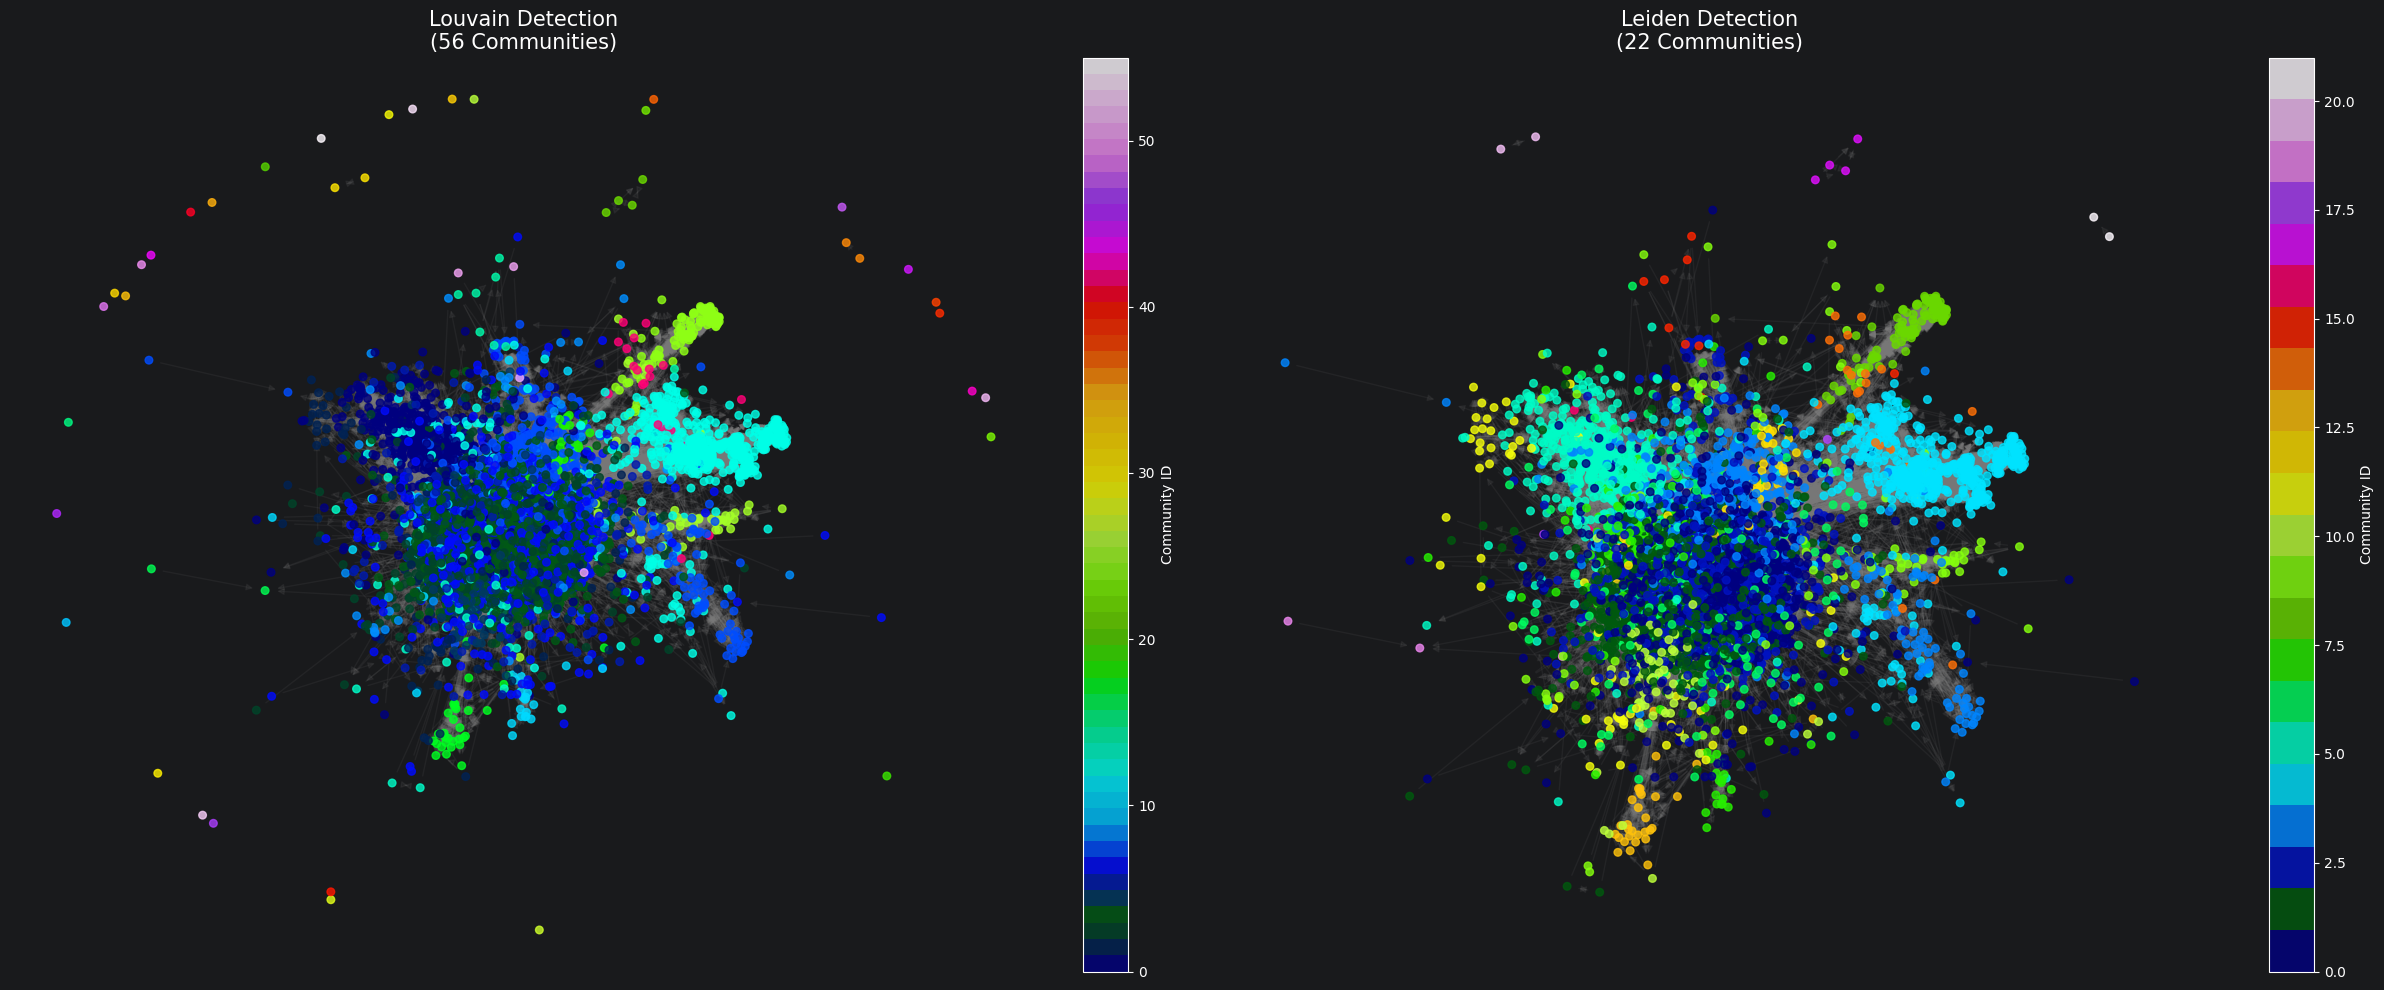

In [7]:
# Create plot for visual comparison
pos = nx.spring_layout(G, k=0.15, seed=42)

# Create figure with two subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Function to draw communities with consistent coloring and layout
def draw_community_plot(ax, partition, title):
    # Assign colors based on community IDs
    unique_comms = len(set(partition.values()))
    cmap = plt.get_cmap('gist_ncar', unique_comms)
    node_colors = [partition.get(node) for node in G.nodes()]

    # Draw nodes and edges
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30,
                                   node_color=node_colors, cmap=cmap, alpha=0.8)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, edge_color='gray')
    ax.set_title(f"{title}\n({unique_comms} Communities)", fontsize=15)
    ax.axis('off')
    return nodes

# 3. Plot Louvain
nodes_louvain = draw_community_plot(axes[0], partition_louvain, "Louvain Detection")
fig.colorbar(nodes_louvain, ax=axes[0], label="Community ID", fraction=0.046, pad=0.04)

# 4. Plot Leiden
nodes_leiden = draw_community_plot(axes[1], partition_leiden, "Leiden Detection")
fig.colorbar(nodes_leiden, ax=axes[1], label="Community ID", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("enron_community_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# 1. List of Community Structure Metrics (Top 5 largest communities)
print("### 1. Community Structure Metrics (Sample) ###")
# We use the metrics already computed in your df_metrics
display_cols = ['community_id', 'size', 'internal_density', 'avg_internal_degree', 'external_connectivity']
print(df_metrics.sort_values('size', ascending=False)[display_cols].head(5).to_string(index=False))

print("\n" + "-"*50 + "\n")

# 2. List of Anomalies: Covert Groups
# These are the dense, isolated groups you identified in Cell 5
print("### 2. Anomaly: Covert Groups (High Density, Low Conductance) ###")
if not covert_groups.empty:
    print(covert_groups[['community_id', 'size', 'internal_density', 'conductance']].to_string(index=False))
else:
    print("No covert groups found with current thresholds.")

print("\n" + "-"*50 + "\n")

# 3. List of Anomalies: Bridge Nodes
# Fixing the interrupted calculation using k=50 for speed
print("### 3. Anomaly: Top 10 Bridge Nodes (Structural Importance) ###")
betweenness_fast = nx.betweenness_centrality(G, weight='distance', k=50, seed=42)
top_bridges = sorted(betweenness_fast.items(), key=lambda x: x[1], reverse=True)[:10]

for i, (node, score) in enumerate(top_bridges, 1):
    print(f"{i}. User: {node} | Betweenness Score: {score:.4f}")

### 1. Community Structure Metrics (Sample) ###
 community_id  size  internal_density  avg_internal_degree  external_connectivity
            0  1321          0.011682            30.841787                  10653
            1  1182          0.010616            25.076142                  13822
            2   908          0.020152            36.555066                   9075
            3   615          0.029165            35.814634                   6085
            4   594          0.027705            32.858586                    704

--------------------------------------------------

### 2. Anomaly: Covert Groups (High Density, Low Conductance) ###
 community_id  size  internal_density  conductance
           17     4          0.666667          0.0
           20     2          1.000000          0.0
           21     2          0.500000          0.0

--------------------------------------------------

### 3. Anomaly: Top 10 Bridge Nodes (Structural Importance) ###
1. User: 585 | Betwe

C:\Users\beark\AppData\Local\Temp\ipykernel_17904\1044272224.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\beark\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


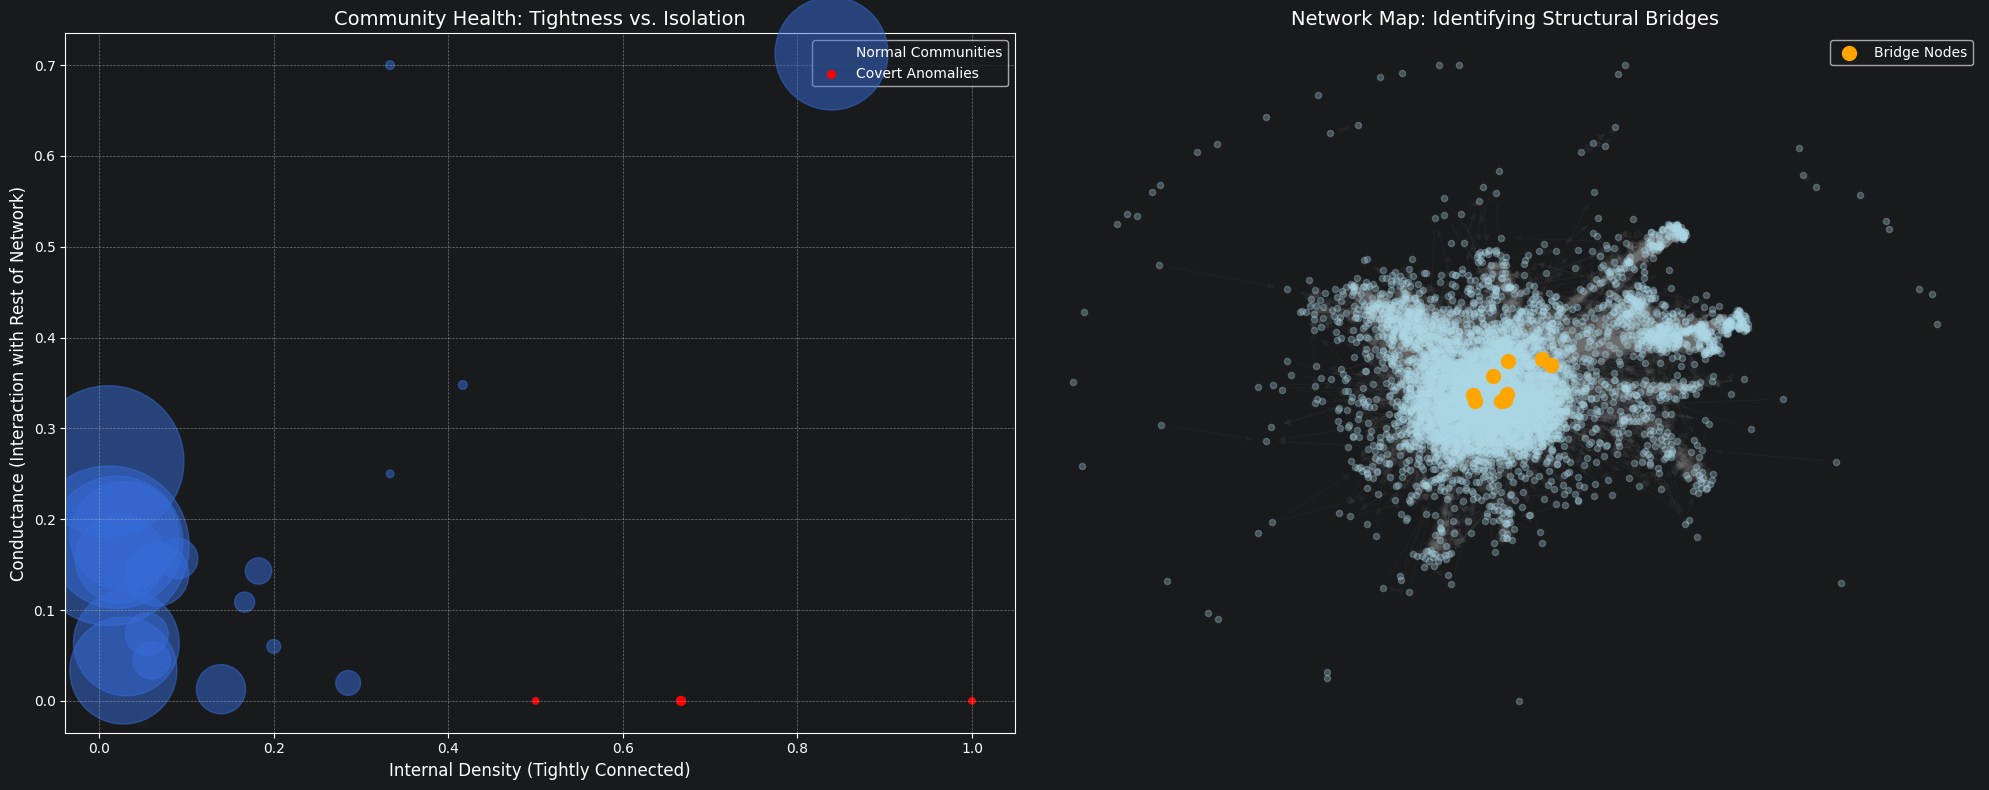

In [9]:
# Create a 1x2 visualization layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Graph A: Metric Distribution (Density vs. Conductance)
ax1.scatter(df_metrics['internal_density'], df_metrics['conductance'],
            s=df_metrics['size']*10, alpha=0.5, label='Normal Communities')

# Highlight covert groups in red
if not covert_groups.empty:
    ax1.scatter(covert_groups['internal_density'], covert_groups['conductance'],
                s=covert_groups['size']*10, color='red', label='Covert Anomalies')

ax1.set_title("Community Health: Tightness vs. Isolation", fontsize=14)
ax1.set_xlabel("Internal Density (Tightly Connected)", fontsize=12)
ax1.set_ylabel("Conductance (Interaction with Rest of Network)", fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# Graph B: Highlighting Bridge Nodes in the Network
# Reuse your existing 'pos' if defined, or create a new one
pos_viz = nx.spring_layout(G, k=0.15, seed=42)
bridge_nodes = [n for n, s in top_bridges]

# Draw background nodes and edges
nx.draw_networkx_edges(G, pos_viz, ax=ax2, alpha=0.05, edge_color='gray')
nx.draw_networkx_nodes(G, pos_viz, ax=ax2, node_size=20, node_color='lightblue', alpha=0.3)

# Highlight bridge nodes in orange
nx.draw_networkx_nodes(G, pos_viz, ax=ax2, nodelist=bridge_nodes,
                       node_size=100, node_color='orange', label='Bridge Nodes')

ax2.set_title("Network Map: Identifying Structural Bridges", fontsize=14)
ax2.legend()
ax2.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# --- List 1: Top Communities by Size ---
print("### Top 5 Communities by Size ###")
cols = ['community_id', 'size', 'internal_density', 'avg_internal_degree', 'external_connectivity']
print(df_metrics.sort_values('size', ascending=False)[cols].head(5).to_string(index=False))

print("\n" + "="*60 + "\n")

# --- List 2: Identified Covert Anomalies ---
print("### Potential Covert Groups (High Density, Low Conductance) ###")
if not covert_groups.empty:
    print(covert_groups[['community_id', 'size', 'internal_density', 'conductance']].to_string(index=False))
else:
    print("No groups met the specific 'covert' threshold.")

print("\n" + "="*60 + "\n")

# --- List 3: Top 10 Bridge Nodes (Structural Importance) ---
# Optimization: Using 'k' to avoid the KeyboardInterrupt you experienced
print("### Top 10 Structural Bridge Nodes ###")
betweenness_fast = nx.betweenness_centrality(G, weight='distance', k=min(50, len(G)), seed=42)
top_bridges = sorted(betweenness_fast.items(), key=lambda x: x[1], reverse=True)[:10]

for i, (node, score) in enumerate(top_bridges, 1):
    print(f"{i}. User: {node} | Betweenness: {score:.4f}")

### Top 5 Communities by Size ###
 community_id  size  internal_density  avg_internal_degree  external_connectivity
            0  1321          0.011682            30.841787                  10653
            1  1182          0.010616            25.076142                  13822
            2   908          0.020152            36.555066                   9075
            3   615          0.029165            35.814634                   6085
            4   594          0.027705            32.858586                    704


### Potential Covert Groups (High Density, Low Conductance) ###
 community_id  size  internal_density  conductance
           17     4          0.666667          0.0
           20     2          1.000000          0.0
           21     2          0.500000          0.0


### Top 10 Structural Bridge Nodes ###
1. User: 585 | Betweenness: 0.3353
2. User: 5556 | Betweenness: 0.1057
3. User: 4390 | Betweenness: 0.0928
4. User: 4377 | Betweenness: 0.0920
5. User: 802 | Betwe

C:\Users\beark\AppData\Local\Temp\ipykernel_17904\133192676.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\beark\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


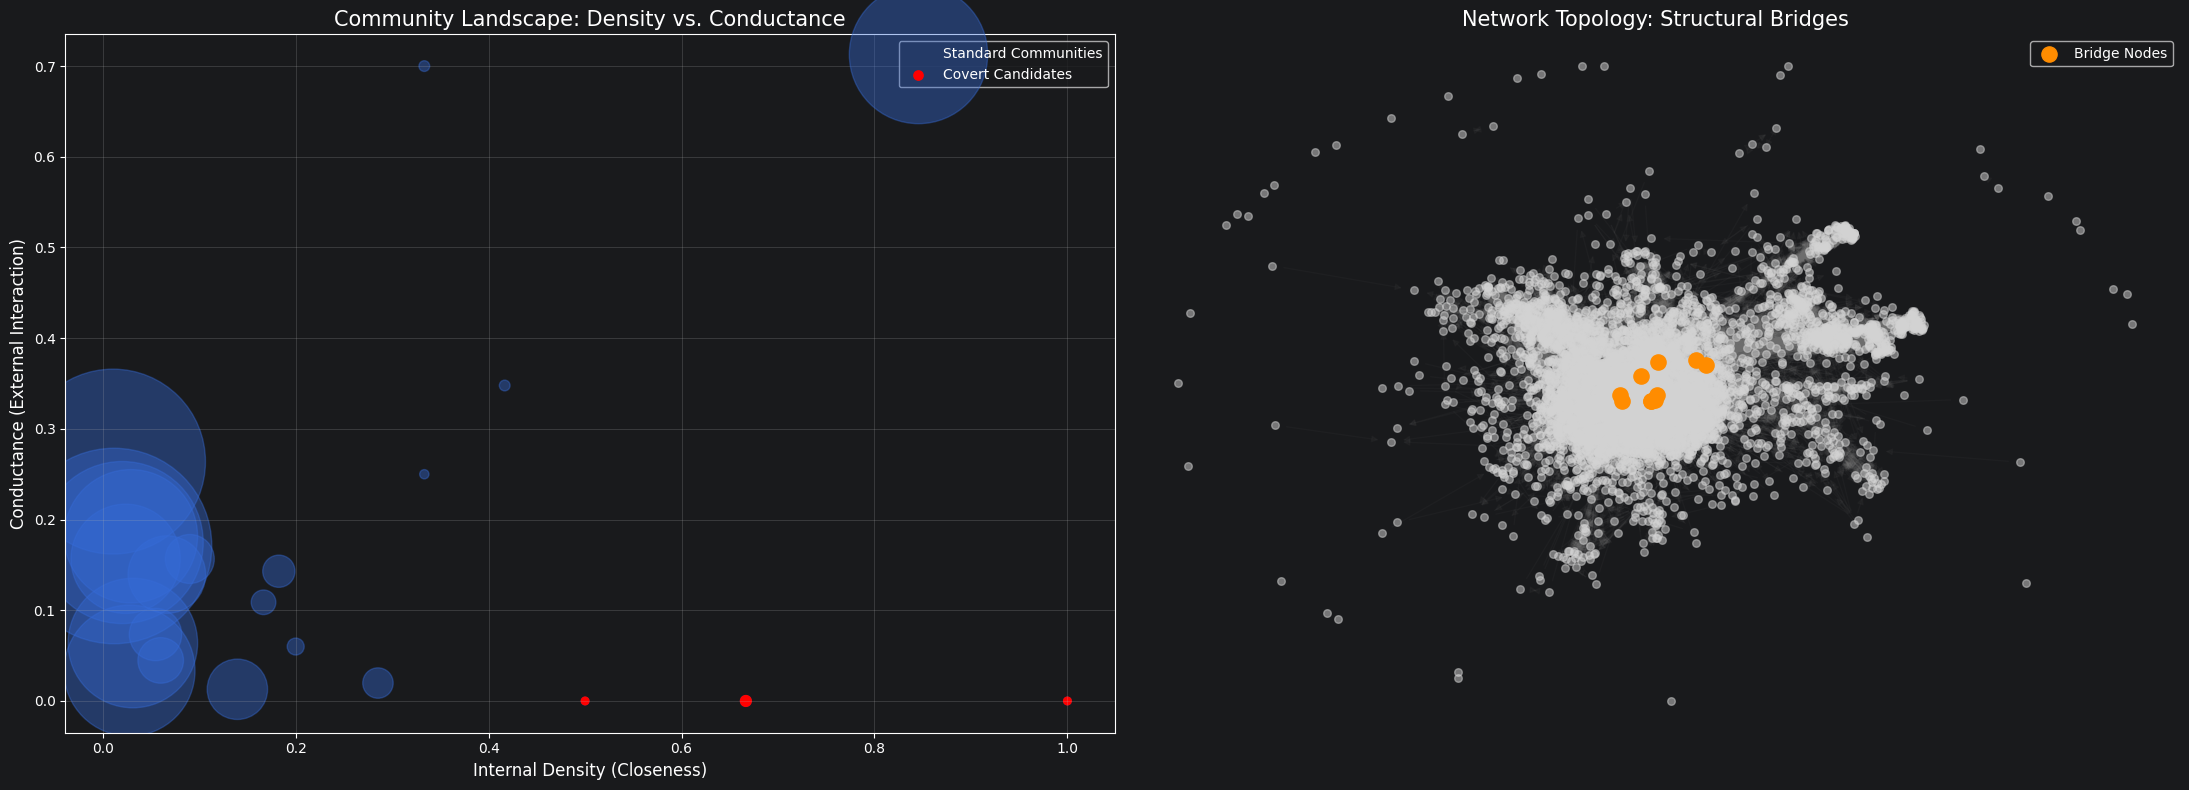

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Graph 1: The "Anomalies" Scatter Plot
ax1.scatter(df_metrics['internal_density'], df_metrics['conductance'],
            s=df_metrics['size']*15, alpha=0.4, label='Standard Communities')
if not covert_groups.empty:
    ax1.scatter(covert_groups['internal_density'], covert_groups['conductance'],
                s=covert_groups['size']*15, color='red', label='Covert Candidates')

ax1.set_title("Community Landscape: Density vs. Conductance", fontsize=15)
ax1.set_xlabel("Internal Density (Closeness)", fontsize=12)
ax1.set_ylabel("Conductance (External Interaction)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graph 2: Highlighted Network Bridges
pos_viz = nx.spring_layout(G, k=0.15, seed=42)
bridge_nodes = [n for n, s in top_bridges]

nx.draw_networkx_edges(G, pos_viz, ax=ax2, alpha=0.05, edge_color='gray')
nx.draw_networkx_nodes(G, pos_viz, ax=ax2, node_size=30, node_color='lightgray', alpha=0.5)
nx.draw_networkx_nodes(G, pos_viz, ax=ax2, nodelist=bridge_nodes,
                       node_size=120, node_color='darkorange', label='Bridge Nodes')

ax2.set_title("Network Topology: Structural Bridges", fontsize=15)
ax2.legend()
ax2.axis('off')

plt.tight_layout()
plt.show()